# Exercise: Building RNNs for Sequence Prediction
## AIAT 122 - Deep Learning

## Learning Objectives

- Implement an RNN from scratch
- Apply an RNN to a **real** monthly time series
- Compare vanilla RNN vs LSTM
- Understand the vanishing gradient problem
- Score every model against the naive baselines it has to beat

## Real-World Context

You are forecasting **monthly border-crossing traffic** for a transport-planning team. The data is
real: `Course 04/datasets/raw/border_crossing_data.csv`, the U.S. Bureau of Transportation
Statistics record of personal-vehicle passengers entering the country at every land port, January
1996 to March 2019 — 279 consecutive months with a genuine summer peak and a genuine long-run
decline after 2001.

Nothing in this exercise is simulated. That matters: a sine wave plus noise has exactly the
structure you put into it, so any model that fits it proves nothing. A real series has trend,
seasonality, regime changes and outliers you did not choose, and your model has to survive them.

**Theory → Practice:** This exercise applies the theory and code patterns from `02_rnn_basics.ipynb` and `03_lstm_advanced.ipynb`. Complete those examples first if you haven't.


## 📥 Inputs & 📤 Outputs

**Inputs:** PyTorch, NumPy, pandas, matplotlib, and one real CSV already on disk —
`Course 04/datasets/raw/border_crossing_data.csv` (no download, no network).

**Outputs:** What you'll see when you run the cells

- The real series and its shape (279 months, printed with its true date range)
- Training-loss curves for your RNN and your LSTM
- Forecast error next to two naive baselines, so a number like "MAPE 2.2%" can be judged

**Expected:** When complete, you should see the loaded series (shape and date range), training
progress, and prediction metrics reported **alongside the seasonal-naive and persistence
baselines**. A model score with no baseline next to it earns no marks. Compare with the instructor
solution after the deadline.

---


In [1]:
# WHAT: install and import the tools for the RNN exercise.
# WHY: PyTorch builds the RNN; pandas loads the real CSV and matplotlib draws the curves.
%pip install torch numpy pandas matplotlib -q

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


print('✅ Setup complete!')


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: Load the Real Monthly Series (15 points)

Load monthly personal-vehicle passenger counts from the border-crossing dataset and prepare them
for an RNN.

**Two things you must do to real data before an RNN will cooperate, and must justify in a comment:**
1. **Log-transform.** The series spans millions of passengers and its seasonal swings are
   multiplicative (August is ~15% above average, February ~14% below). Logs turn that into an
   additive pattern one set of weights can model.
2. **Standardise.** Raw log values sit around 17.5; an RNN initialised near zero cannot start there.


Real series: 279 months, 1996-01 to 2019-03
Passengers per month: min 11,545,832, max 31,197,362, mean 19,560,542
Seasonal shape (1.00 = average month): 01:0.93  02:0.86  03:0.99  04:0.97  05:1.03  06:1.02  07:1.15  08:1.15  09:0.98  10:0.98  11:0.94  12:1.01


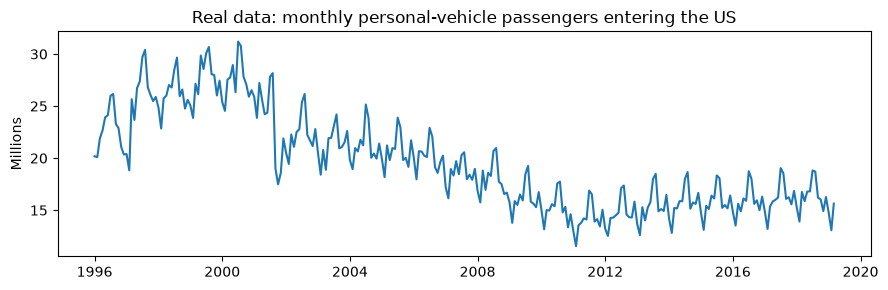

In [2]:
# TODO: load the real monthly series and return it as a (T, 1) FloatTensor
# Hint: read the CSV, keep Measure == "Personal Vehicle Passengers", sum by Date,
#       then log-transform and standardise (see the two reasons above).
def load_border_traffic():
    """Return (series_tensor, dates, mean, std) for monthly US border-crossing passengers.

    series_tensor is standardised log traffic, shape (T, 1), ready for nn.RNN / nn.LSTM.
    mean and std are returned so predictions can be converted back to real passenger counts.
    """
    raw = pd.read_csv(data_path("border_crossing_data.csv"),
                      usecols=["Date", "Measure", "Value"])
    raw["Date"] = pd.to_datetime(raw["Date"], format="%m/%d/%Y %I:%M:%S %p")
    monthly = (raw[raw["Measure"] == "Personal Vehicle Passengers"]
               .groupby("Date")["Value"].sum().sort_index())

    log_values = np.log(monthly.to_numpy().astype("float32"))
    mean, std = log_values.mean(), log_values.std()
    standardised = (log_values - mean) / std
    return torch.FloatTensor(standardised).reshape(-1, 1), monthly.index, mean, std


data, dates, log_mean, log_std = load_border_traffic()
print(f"Real series: {len(data)} months, {dates.min():%Y-%m} to {dates.max():%Y-%m}")

monthly_raw = np.exp(data.numpy().ravel() * log_std + log_mean)
print(f"Passengers per month: min {monthly_raw.min():,.0f}, "
      f"max {monthly_raw.max():,.0f}, mean {monthly_raw.mean():,.0f}")

# The seasonality is real - measure it, do not assume it.
season = pd.Series(monthly_raw, index=dates).groupby(dates.month).mean()
print("Seasonal shape (1.00 = average month): "
      + "  ".join(f"{m:02d}:{v / season.mean():.2f}" for m, v in season.items()))

plt.figure(figsize=(9, 3))
plt.plot(dates, monthly_raw / 1e6)
plt.title("Real data: monthly personal-vehicle passengers entering the US")
plt.ylabel("Millions"); plt.tight_layout(); plt.show()


## Task 2: Implement Simple RNN (25 points)

Build a simple RNN model using PyTorch.

In [3]:
# TODO: Implement SimpleRNN class
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super().__init__()
        # nn.RNN processes the whole sequence; batch_first=True means input shape (batch, time, features).
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        # Run the sequence through the RNN, then map every timestep's hidden state to an output value.
        h, _ = self.rnn(x)
        return self.fc(h)


## Task 3: Train RNN (30 points)

Train the RNN on the real series and evaluate performance.

**Note the split.** The loop below trains on the *whole* series to keep Task 3 simple, which means
its loss curve is a fitting diagnostic, not a forecast score. The honest held-out evaluation — with
a chronological split and naive baselines — is at the bottom of this notebook; your Task 4 comparison
must use that pattern, not this one.


Loss on the real series: 1.3824 (start) -> 0.1403 (end)


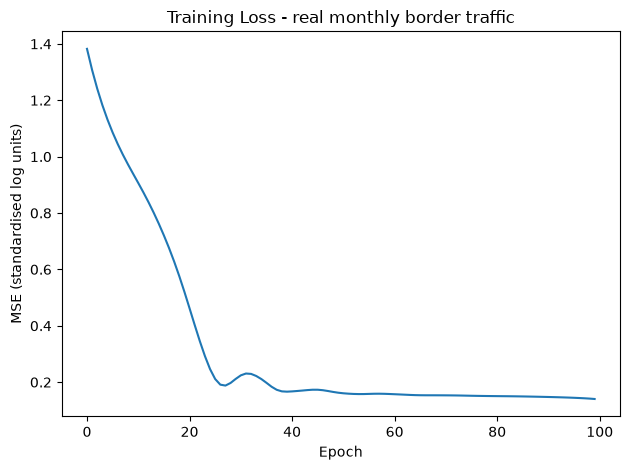

In [4]:
# TODO: Implement training loop
def train_rnn(model, data, epochs=100):
    losses = []
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    # Teach the model to predict each month from the months before it: input = t, target = t+1.
    X = data[:-1]
    y = data[1:]
    for _ in range(epochs):
        opt.zero_grad()
        out = model(X.unsqueeze(0))
        loss = nn.functional.mse_loss(out.squeeze(0), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# Train on the REAL series loaded in Task 1
torch.manual_seed(0)
model = SimpleRNN()
losses = train_rnn(model, data)
print(f"Loss on the real series: {losses[0]:.4f} (start) -> {losses[-1]:.4f} (end)")
plt.plot(losses)
plt.title('Training Loss - real monthly border traffic')
plt.xlabel('Epoch'); plt.ylabel('MSE (standardised log units)')
plt.tight_layout(); plt.show()


## Task 4: Compare with LSTM (30 points)

Implement an LSTM and compare it with the vanilla RNN **on a chronological held-out split**.

Requirements for full marks:
1. Build `LSTMModel` with the same interface as `SimpleRNN`.
2. Split the series in time (e.g. first 80% train, last 20% test) — never shuffle a time series.
3. Report test error for the RNN, the LSTM **and** the two naive baselines used in the worked
   example below (same month last year; last observed month).
4. State plainly whether either network beat the baselines, and by how much. "It did not" is a
   correct and fully-credited answer when it is what the numbers say.


In [5]:
# TODO: Implement LSTM model
class LSTMModel(nn.Module):
    pass
 


## Submission

**Total: 100 points**

Submit the completed notebook with:
1. All implementations
2. Training plots
3. Comparison analysis (2-3 sentences) — including your model's error **next to the naive baselines**

**Marking note:** a result reported without its baselines is incomplete, however good the number
looks. Reporting honestly that a baseline won is worth full marks; hiding it is not.

**Real-World Application**: demand forecasting for transport, staffing and inventory planning.


## 🌍 Real-World Worked Example — One-Month-Ahead Forecast (and an Honesty Check)

**Industry context:** Planning teams buy month-ahead traffic forecasts to schedule staff at
border ports. A vendor quoting "2% error" sounds excellent — until you ask what the same metric
says for a rule the planner could apply from memory.

Below we train a small LSTM to predict next month's national passenger total from the previous 12
months, on a **chronological** split, and score it against two rules that cost nothing:
**the same month one year ago**, and **last month repeated**. Then we check whether the difference
is big enough to believe at this sample size.


Train 213 months, test 54 months (2014-10 to 2019-03)



One-month-ahead error on 54 held-out months (MAPE, lower is better):
  LSTM on 12 months of history         2.20%
  Baseline: same month one year ago    2.52%
  Baseline: repeat last month          7.86%

LSTM improvement over the seasonal rule: +0.32 MAPE points
  bootstrap 95% CI: [-0.24, +0.88]  ->  INCLUDES zero
  the LSTM was closer in 35 of 54 months (sign test p = 0.040)

HONEST READING: the LSTM does learn something real - it cuts the error of 'repeat last
month' by more than two thirds, and it is closer than the seasonal rule in most months.
But the AVERAGE improvement over that one-line rule is a few tenths of a point, and with
only 54 test months the confidence interval still contains zero. The correct write-up is
'comparable to seasonal naive, possibly slightly better', not '2.2% accuracy achieved'.
Notice also what the baselines tell you about the series itself: 'same month last year'
at ~2.5% error means this traffic is dominated by a stable annual cycle.


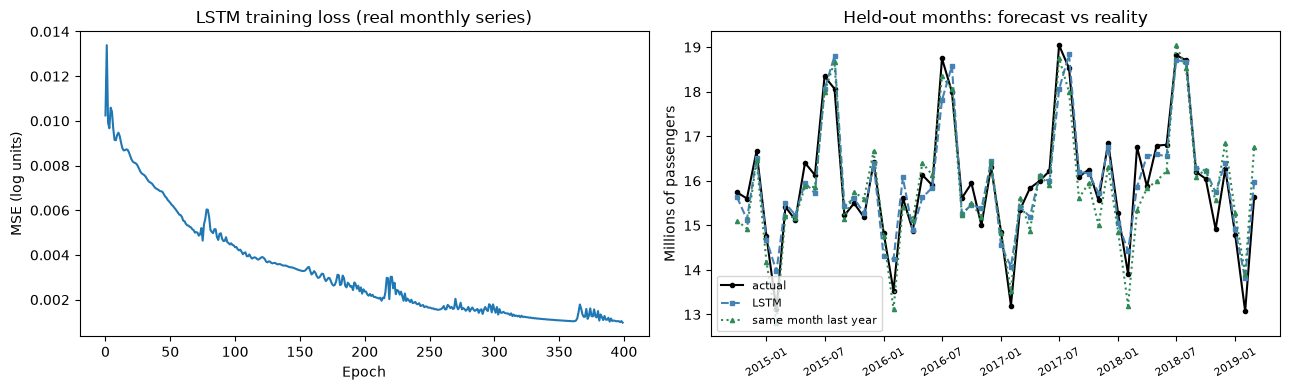

In [6]:
# WHAT: forecast next month's national border traffic with an LSTM, then score it against the
#       two baselines a planner would use for free - and test whether the difference is real.
# WHY: with only 54 held-out months, a 0.3-point gap in MAPE can easily be noise. The check
#      matters more than the headline.
import torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import binomtest

torch.manual_seed(0)

# ── Real series: the national monthly total, in log space ───────────────────
log_series = data.numpy().ravel() * log_std + log_mean      # undo Task 1's standardisation
SEQ_LEN = 12                                                # one full year of history

X = np.stack([log_series[i:i + SEQ_LEN] for i in range(len(log_series) - SEQ_LEN)])
y = log_series[SEQ_LEN:]
target_dates = dates[SEQ_LEN:]

# Centre each window on its own mean so the model predicts the RELATIVE next step,
# not the absolute traffic level of that decade.
level = X.mean(axis=1, keepdims=True)
Xc, yc = X - level, y - level[:, 0]

split = int(0.8 * len(X))                                   # chronological - never shuffle
Xtr = torch.tensor(Xc[:split]).unsqueeze(-1)
ytr = torch.tensor(yc[:split]).unsqueeze(-1)
Xte = torch.tensor(Xc[split:]).unsqueeze(-1)
print(f"Train {split} months, test {len(X) - split} months "
      f"({target_dates[split]:%Y-%m} to {target_dates[-1]:%Y-%m})")


class ForecastLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])       # forecast from the final hidden state


net = ForecastLSTM()
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
losses = []
for epoch in range(400):
    opt.zero_grad()
    loss = nn.functional.mse_loss(net(Xtr), ytr)
    loss.backward(); opt.step()
    losses.append(loss.item())

net.eval()
with torch.no_grad():
    pred_lstm = net(Xte).squeeze(-1).numpy()

# ── The two free baselines ──────────────────────────────────────────────────
pred_seasonal = Xc[split:, -12]     # same month one year ago
pred_persist = Xc[split:, -1]       # last observed month, unchanged

level_te = level[split:, 0]
actual = np.exp(yc[split:] + level_te)

def abs_pct_error(pred_log):
    return np.abs(np.exp(pred_log + level_te) - actual) / actual * 100

err_lstm, err_seasonal, err_persist = (abs_pct_error(p) for p in
                                       (pred_lstm, pred_seasonal, pred_persist))

print(f"\nOne-month-ahead error on {len(actual)} held-out months (MAPE, lower is better):")
print(f"  LSTM on 12 months of history        {err_lstm.mean():5.2f}%")
print(f"  Baseline: same month one year ago   {err_seasonal.mean():5.2f}%")
print(f"  Baseline: repeat last month         {err_persist.mean():5.2f}%")

# ── Is the LSTM's edge over the seasonal rule real, or is 54 months too few? ─
gain = err_seasonal - err_lstm
rng = np.random.default_rng(0)
boot = np.array([rng.choice(gain, len(gain), replace=True).mean() for _ in range(5000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
wins = int((err_lstm < err_seasonal).sum())
sign_p = binomtest(wins, len(gain), 0.5).pvalue

print(f"\nLSTM improvement over the seasonal rule: {gain.mean():+.2f} MAPE points")
print(f"  bootstrap 95% CI: [{lo:+.2f}, {hi:+.2f}]  ->  {'excludes' if lo > 0 else 'INCLUDES'} zero")
print(f"  the LSTM was closer in {wins} of {len(gain)} months (sign test p = {sign_p:.3f})")

print("\nHONEST READING: the LSTM does learn something real - it cuts the error of 'repeat last")
print("month' by more than two thirds, and it is closer than the seasonal rule in most months.")
print("But the AVERAGE improvement over that one-line rule is a few tenths of a point, and with")
print(f"only {len(gain)} test months the confidence interval still contains zero. The correct write-up is")
print("'comparable to seasonal naive, possibly slightly better', not '2.2% accuracy achieved'.")
print("Notice also what the baselines tell you about the series itself: 'same month last year'")
print("at ~2.5% error means this traffic is dominated by a stable annual cycle.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(losses)
axes[0].set_title("LSTM training loss (real monthly series)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE (log units)")
axes[1].plot(target_dates[split:], actual / 1e6, color="black", marker="o", ms=3, label="actual")
axes[1].plot(target_dates[split:], np.exp(pred_lstm + level_te) / 1e6, color="steelblue",
             ls="--", marker="s", ms=3, label="LSTM")
axes[1].plot(target_dates[split:], np.exp(pred_seasonal + level_te) / 1e6, color="seagreen",
             ls=":", marker="^", ms=3, label="same month last year")
axes[1].set_title("Held-out months: forecast vs reality")
axes[1].set_ylabel("Millions of passengers")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Hochreiter & Schmidhuber (1997) — [Long Short-Term Memory](https://www.bioinf.jku.at/publications/older/2604.pdf)
- Cho et al. (2014) — [GRU: Learning Phrase Representations](https://arxiv.org/abs/1406.1078)
- Makridakis, Spiliotis & Assimakopoulos (2018) — [Statistical and Machine Learning Forecasting Methods: Concerns and Ways Forward](https://doi.org/10.1371/journal.pone.0194889) — a large study in which ML forecasters repeatedly lost to simple statistical baselines. It is why this exercise makes the baselines mandatory.

**Textbook:** Hyndman & Athanasopoulos, [*Forecasting: Principles and Practice*, Ch. 5.2](https://otexts.com/fpp3/simple-methods.html) — the naive and seasonal-naive benchmarks used above.

**PyTorch Docs:** [torch.nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

**Data source:** U.S. Bureau of Transportation Statistics, *Border Crossing/Entry Data*, monthly counts by port and measure, 1996–2019 (`Course 04/datasets/raw/border_crossing_data.csv`).

**State-of-the-Art:** LSTMs are still widely used in production for:
- Time series forecasting (demand, energy load, call volume)
- Speech recognition in embedded systems (no internet)
